# Attention Is All You Need — walkthrough

A guided tour of the from-scratch Transformer in `model.py`: attention on a toy example,
positional encodings, the trained Multi30k De→En model, its attention maps, the KV cache,
and an ablation that shows why positional encoding is necessary.

Run top to bottom; needs `checkpoints/multi30k_best.pt` from `python translate.py train`.

In [1]:
import math, time
import torch                      # import torch before matplotlib (OpenMP clash on Anaconda)
import matplotlib.pyplot as plt
import torch.nn.functional as F

from model import scaled_dot_product_attention, MultiHeadAttention, PositionalEncoding, Transformer
from data import load_multi30k, tokenize, collate, BOS, EOS, PAD
from translate import load_best
torch.manual_seed(0)

## 1. Scaled dot-product attention on a toy example

Three "tokens" with 4-dim keys. Query 0 is built to match key 2, so its attention row
should concentrate there. Every row of the weight matrix sums to 1.

In [2]:
k = torch.tensor([[1., 0, 0, 0], [0, 1., 0, 0], [0, 0, 1., 0]])   # 3 keys
v = torch.tensor([[10., 0], [0, 10.], [5., 5.]])                      # 3 values
q = torch.tensor([[0, 0, 3., 0]])                                     # query aligned with key 2
out, attn = scaled_dot_product_attention(q[None, None], k[None, None], v[None, None])
print("attention weights:", attn[0, 0, 0].numpy().round(3), " sum =", attn.sum().item())
print("output          :", out[0, 0, 0].numpy().round(2), " (mostly value 2 = [5, 5])")

attention weights: [0.154 0.154 0.691]  sum = 1.0
output          : [5. 5.]  (mostly value 2 = [5, 5])


**Why divide by √d_k?** With unit-variance q and k, the dot product has variance d_k.
Without scaling, softmax saturates as d_k grows and gradients vanish.

In [3]:
for d in [4, 64, 512]:
    q, k = torch.randn(1, 1, 1, d), torch.randn(1, 1, 8, d)
    raw = (q @ k.transpose(-2, -1)).squeeze()
    print(f"d_k={d:4d}  raw score std {raw.std():5.2f}   scaled std {(raw / math.sqrt(d)).std():4.2f}   "
          f"max softmax weight (unscaled) {F.softmax(raw, -1).max():.2f}")

d_k=   4  raw score std  1.90   scaled std 0.95   max softmax weight (unscaled) 0.43
d_k=  64  raw score std  5.64   scaled std 0.71   max softmax weight (unscaled) 0.99
d_k= 512  raw score std 20.18   scaled std 0.89   max softmax weight (unscaled) 0.63


## 2. Sinusoidal positional encoding

Each dimension is a sinusoid; wavelengths grow geometrically from 2π to 10000·2π. A useful
property: the encoding of position `pos+k` is a linear function of the encoding of `pos`,
so attention can learn to look at relative offsets.

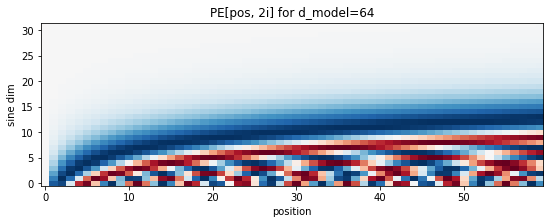

cos-sim of position 10 with positions 8..13: [0.88 0.97 1.   0.97 0.88 0.8 ]


In [4]:
pe = PositionalEncoding(64, dropout=0.0, max_len=60).pe[0]
fig, ax = plt.subplots(figsize=(9, 3))
ax.imshow(pe[:, 0::2].T, aspect="auto", cmap="RdBu", origin="lower")
ax.set_xlabel("position"); ax.set_ylabel("sine dim"); ax.set_title("PE[pos, 2i] for d_model=64")
plt.show()
# Nearby positions are more similar than distant ones:
sim = F.cosine_similarity(pe[10][None], pe, dim=-1)
print("cos-sim of position 10 with positions 8..13:", sim[8:14].numpy().round(2))

## 3. The trained De→En model

In [5]:
model, ckpt = load_best(torch.device("cpu"))
src_stoi = {w: i for i, w in enumerate(ckpt["src_itos"])}
tgt_itos = ckpt["tgt_itos"]
print(f"epoch {ckpt['epoch']} checkpoint, val BLEU {ckpt['val_bleu']:.1f}, "
      f"{sum(p.numel() for p in model.parameters()):,} parameters")

def encode_de(sentence):
    return torch.tensor([[src_stoi.get(w, 3) for w in tokenize(sentence)]])

def decode_en(ids):
    return " ".join(tgt_itos[i] for i in ids[1:] if i not in (PAD, EOS))

sentences = ["ein mann fährt fahrrad .",
             "zwei hunde spielen im schnee .",
             "eine frau in einem roten kleid steht vor einem gebäude .",
             "drei kinder sitzen auf einer bank und essen eis ."]
for s in sentences:
    src = encode_de(s)
    g = decode_en(model.greedy_decode(src, BOS, EOS)[0].tolist())
    b = decode_en(model.beam_search(src, BOS, EOS, beam_size=4)[0])
    print(f"DE     : {s}\ngreedy : {g}\nbeam 4 : {b}\n")

epoch 19 checkpoint, val BLEU 41.1, 9,063,178 parameters
DE     : ein mann fährt fahrrad .
greedy : a man is riding a bicycle .
beam 4 : a man is riding a bicycle .

DE     : zwei hunde spielen im schnee .
greedy : two dogs are playing in the snow .
beam 4 : two dogs play in the snow .

DE     : eine frau in einem roten kleid steht vor einem gebäude .
greedy : a woman in a red dress is standing in front of a building .
beam 4 : a woman in a red dress is standing in front of a building .

DE     : drei kinder sitzen auf einer bank und essen eis .
greedy : three children are sitting on a bench eating ice cream .
beam 4 : three children are sitting on a bench eating ice cream .



## 4. What the heads look at

Cross-attention weights from the last decoder layer. Each row is an English output token,
each column a German input token. The model was never given alignments; the diagonal
emerges from the translation objective alone.

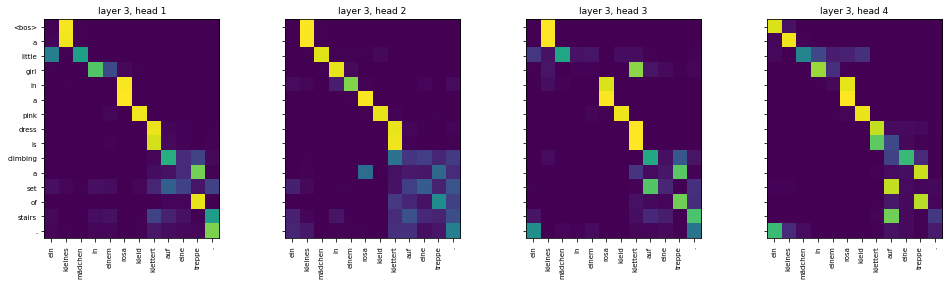

EN: a little girl in a pink dress is climbing a set of stairs .


In [6]:
sentence = "ein kleines mädchen in einem rosa kleid klettert auf eine treppe ."
src = encode_de(sentence)
out_ids = model.beam_search(src, BOS, EOS, beam_size=4)[0]
tgt_in = torch.tensor([out_ids[:-1]])
with torch.no_grad():
    model(src, tgt_in)                      # teacher-forced pass fills every layer's .attn
src_words = tokenize(sentence)
tgt_words = [tgt_itos[i] for i in tgt_in[0].tolist()]
attn = model.decoder.layers[-1].cross_attn.attn[0]   # (H, T, S)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for h, ax in enumerate(axes):
    ax.imshow(attn[h], cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(src_words))); ax.set_xticklabels(src_words, rotation=90, fontsize=7)
    ax.set_yticks(range(len(tgt_words))); ax.set_yticklabels(tgt_words if h == 0 else [], fontsize=7)
    ax.set_title(f"layer 3, head {h + 1}", fontsize=9)
plt.tight_layout(); plt.show()
print("EN:", decode_en(out_ids))

**Attention entropy by layer.** Lower entropy means sharper, more alignment-like attention.
Deeper decoder layers are sharper than the first.

In [7]:
for l, layer in enumerate(model.decoder.layers):
    a = layer.cross_attn.attn[0]                       # (H, T, S)
    ent = -(a * (a + 1e-9).log()).sum(-1).mean().item()
    print(f"decoder layer {l + 1}: mean cross-attention entropy {ent:.2f} nats "
          f"(uniform would be {math.log(a.size(-1)):.2f})")

decoder layer 1: mean cross-attention entropy 1.83 nats (uniform would be 2.48)
decoder layer 2: mean cross-attention entropy 1.03 nats (uniform would be 2.48)
decoder layer 3: mean cross-attention entropy 0.59 nats (uniform would be 2.48)


## 5. The KV cache

Greedy decoding without a cache re-runs the decoder on the whole prefix every step, so
generating T tokens costs O(T²) decoder work. With cached keys and values, each step
processes only the newest token.

In [8]:
_, _, test, sv, tv = load_multi30k()
batch, _ = collate(test[:128])
for use_cache in (False, True):
    t0 = time.time()
    out = model.greedy_decode(batch, BOS, EOS, max_len=60, use_cache=use_cache)
    print(f"use_cache={use_cache!s:5}  {time.time() - t0:5.2f}s for 128 sentences")
    if use_cache: same = torch.equal(out, ref)
    else: ref = out
print("identical outputs:", same)

use_cache=False   3.35s for 128 sentences
use_cache=True    0.70s for 128 sentences
identical outputs: True


## 6. Ablation: what happens without positional encoding?

Attention is permutation-invariant. Zeroing the positional-encoding buffer at inference
time (the weights are unchanged) leaves the encoder unable to tell word order apart, and
translations degrade even though every token is still "seen".

In [9]:
import copy
no_pos = copy.deepcopy(model)
no_pos.encoder.pos.pe.zero_()
no_pos.decoder.pos.pe.zero_()
for s in ["ein mann fährt fahrrad .", "der hund jagt die katze .", "die katze jagt den hund ."]:
    src = encode_de(s)
    print(f"DE       : {s}")
    print(f"with PE  : {decode_en(model.greedy_decode(src, BOS, EOS)[0].tolist())}")
    print(f"no PE    : {decode_en(no_pos.greedy_decode(src, BOS, EOS)[0].tolist())}\n")

DE       : ein mann fährt fahrrad .
with PE  : a man is riding a bicycle .
no PE    : a man is riding a bike on a bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike bike is riding a man on a bike bike bike bike bike bike

DE       : der hund jagt die katze .
with PE  : the dog is chasing the cat .
no PE    : the dog is chasing the dog on the dog while the dog is chasing the dog in the dog .

DE       : die katze jagt den hund .
with PE  : the cat is chasing the dog .
no PE    : the dog is chasing the cat on the dog while the dog is chasing the dog in the dog .



## Summary

- Attention is a soft dictionary lookup: softmax(QKᵀ/√d_k) gives the weights, V the payload.
- Positional encodings are the only source of order information, and removing them breaks translation.
- The trained model learns word alignment as a by-product; deeper layers attend more sharply.
- A KV cache turns O(T²) autoregressive decoding into O(T) with identical output.

See `README.md` for BLEU results and `test_equivalence.py` for the proof that the
implementation matches `torch.nn.Transformer`.